## 11.3. Attention Scoring Functions

In [1]:
import math
import torch
from torch import nn
from d2l import torch as d2l

### 11.3.2.1. Masked Softmax Operation

In [2]:
def masked_softmax(X, valid_lens):  #@save
    """Perform softmax operation by masking elements on the last axis."""
    # X: 3D tensor, valid_lens: 1D or 2D tensor
    def _sequence_mask(X, valid_len, value=0):
        maxlen = X.size(1)
        mask = torch.arange((maxlen), dtype=torch.float32,
                            device=X.device)[None, :] < valid_len[:, None]
        X[~mask] = value
        return X

    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)
    else:
        shape = X.shape
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)
        # On the last axis, replace masked elements with a very large negative
        # value, whose exponentiation outputs 0
        X = _sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e6)
        return nn.functional.softmax(X.reshape(shape), dim=-1)

In [33]:
X_test = torch.rand(2, 2, 4)
X_test.shape, X_test

(torch.Size([2, 2, 4]),
 tensor([[[0.2895, 0.5565, 0.2186, 0.1504],
          [0.2621, 0.5939, 0.2712, 0.2268]],
 
         [[0.1247, 0.8641, 0.7177, 0.9513],
          [0.2359, 0.4139, 0.8193, 0.2931]]]))

In [30]:
torch.repeat_interleave(torch.tensor([2, 3]), X_test.shape[1])

tensor([2, 2, 3, 3])

In [32]:
X_test.reshape(-1, X_test.shape[-1]).shape, X_test.reshape(-1, X_test.shape[-1])

(torch.Size([4, 4]),
 tensor([[0.4901, 0.5441, 0.0111, 0.5382],
         [0.3330, 0.1400, 0.4751, 0.5592],
         [0.5436, 0.3861, 0.1356, 0.8348],
         [0.0049, 0.3464, 0.4374, 0.5094]]))

In [35]:
torch.arange((4), dtype=torch.float32,device=X_test.device)[None, :]

tensor([[0., 1., 2., 3.]])

In [36]:
torch.repeat_interleave(torch.tensor([2, 3]), X_test.shape[1])[:, None]

tensor([[2],
        [2],
        [3],
        [3]])

In [47]:
torch.arange(4).reshape(1, 4), torch.tensor([2, 1, 4, 1]).reshape(4, 1), torch.arange(4).reshape(1, 4) < torch.tensor([2, 1, 4, 1]).reshape(4, 1)

(tensor([[0, 1, 2, 3]]),
 tensor([[2],
         [1],
         [4],
         [1]]),
 tensor([[ True,  True, False, False],
         [ True, False, False, False],
         [ True,  True,  True,  True],
         [ True, False, False, False]]))

In [34]:
torch.arange((4), dtype=torch.float32,device=X_test.device)[None, :] < torch.repeat_interleave(torch.tensor([2, 3]), X_test.shape[1])[:, None]

tensor([[ True,  True, False, False],
        [ True,  True, False, False],
        [ True,  True,  True, False],
        [ True,  True,  True, False]])

In [26]:
masked_softmax(torch.rand(2, 2, 4), torch.tensor([2, 3]))

tensor([[[0.5040, 0.4960, 0.0000, 0.0000],
         [0.5306, 0.4694, 0.0000, 0.0000]],

        [[0.2826, 0.3747, 0.3427, 0.0000],
         [0.2922, 0.4313, 0.2766, 0.0000]]])

In [50]:
masked_softmax(torch.rand(2, 2, 4), torch.tensor([[1, 3], [2, 4]]))

tensor([[[1.0000, 0.0000, 0.0000, 0.0000],
         [0.4182, 0.3257, 0.2561, 0.0000]],

        [[0.4326, 0.5674, 0.0000, 0.0000],
         [0.3073, 0.1922, 0.2051, 0.2955]]])

### 11.3.2.2. Batch Matrix Multiplication

In [51]:
Q = torch.ones((2, 3, 4))
K = torch.ones((2, 4, 6))
d2l.check_shape(torch.bmm(Q, K), (2, 3, 6))

### 11.3.3. Scaled Dot Product Attention

In [52]:
class DotProductAttention(nn.Module):  #@save
    """Scaled dot product attention."""
    def __init__(self, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

    # Shape of queries: (batch_size, no. of queries, d)
    # Shape of keys: (batch_size, no. of key-value pairs, d)
    # Shape of values: (batch_size, no. of key-value pairs, value dimension)
    # Shape of valid_lens: (batch_size,) or (batch_size, no. of queries)
    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        # Swap the last two dimensions of keys with keys.transpose(1, 2)
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d)
        self.attention_weights = masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)

In [53]:
queries = torch.normal(0, 1, (2, 1, 2))
keys = torch.normal(0, 1, (2, 10, 2))
values = torch.normal(0, 1, (2, 10, 4))
valid_lens = torch.tensor([2, 6])

attention = DotProductAttention(dropout=0.5)
attention.eval()
d2l.check_shape(attention(queries, keys, values, valid_lens), (2, 1, 4))

In [56]:
torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(queries.shape[-1])

tensor([[[ 0.5113,  0.2116,  0.1040,  0.6129, -0.1681, -0.1162,  0.1053,
           0.6333, -0.1843,  0.3982]],

        [[-0.0775,  0.1390, -0.1019, -0.2553, -0.2994, -0.2331,  0.2079,
          -0.4237, -0.0157,  0.3987]]])

In [58]:
attention.attention_weights

tensor([[[0.5744, 0.4256, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000]],

        [[0.1751, 0.2174, 0.1709, 0.1466, 0.1402, 0.1498, 0.0000, 0.0000,
          0.0000, 0.0000]]])

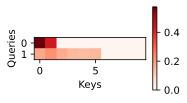

In [57]:
d2l.show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)),
                  xlabel='Keys', ylabel='Queries')

### 11.3.4. Additive Attention

In [60]:
class AdditiveAttention(nn.Module):  #@save
    """Additive attention."""
    def __init__(self, num_hiddens, dropout, **kwargs):
        super(AdditiveAttention, self).__init__(**kwargs)
        self.W_k = nn.LazyLinear(num_hiddens, bias=False)
        self.W_q = nn.LazyLinear(num_hiddens, bias=False)
        self.w_v = nn.LazyLinear(1, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens):
        queries, keys = self.W_q(queries), self.W_k(keys)
        # After dimension expansion, shape of queries: (batch_size, no. of
        # queries, 1, num_hiddens) and shape of keys: (batch_size, 1, no. of
        # key-value pairs, num_hiddens). Sum them up with broadcasting
        features = queries.unsqueeze(2) + keys.unsqueeze(1)
        features = torch.tanh(features)
        # There is only one output of self.w_v, so we remove the last
        # one-dimensional entry from the shape. Shape of scores: (batch_size,
        # no. of queries, no. of key-value pairs)
        scores = self.w_v(features).squeeze(-1)
        self.attention_weights = masked_softmax(scores, valid_lens)
        # Shape of values: (batch_size, no. of key-value pairs, value
        # dimension)
        return torch.bmm(self.dropout(self.attention_weights), values)

In [63]:
test_q = torch.rand(2, 10, 1, 2)
test_k = torch.rand(2, 1, 8, 2)
test_q.shape, test_q.unsqueeze(2).shape, test_k.shape, test_k.unsqueeze(1).shape

(torch.Size([2, 10, 1, 2]),
 torch.Size([2, 10, 1, 1, 2]),
 torch.Size([2, 1, 8, 2]),
 torch.Size([2, 1, 1, 8, 2]))

In [65]:
(test_q.unsqueeze(2) + test_k.unsqueeze(1)).shape

torch.Size([2, 10, 1, 8, 2])

In [66]:
queries = torch.normal(0, 1, (2, 1, 20))

attention = AdditiveAttention(num_hiddens=8, dropout=0.1)
attention.eval()
d2l.check_shape(attention(queries, keys, values, valid_lens), (2, 1, 4))

In [68]:
attention.attention_weights

tensor([[[0.5494, 0.4506, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000]],

        [[0.1643, 0.1263, 0.1608, 0.1809, 0.1695, 0.1982, 0.0000, 0.0000,
          0.0000, 0.0000]]], grad_fn=<SoftmaxBackward0>)

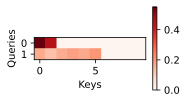

In [67]:
d2l.show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)),
                  xlabel='Keys', ylabel='Queries')

### 11.3.6. Exercises

In [69]:
class DistanceAttention_ex1(nn.Module):
    """Scaled dot product attention."""
    def __init__(self, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

    # Shape of queries: (batch_size, no. of queries, d)
    # Shape of keys: (batch_size, no. of key-value pairs, d)
    # Shape of values: (batch_size, no. of key-value pairs, value dimension)
    # Shape of valid_lens: (batch_size,) or (batch_size, no. of queries)
    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        # Swap the last two dimensions of keys with keys.transpose(1, 2)
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d)
        key_norms = torch.sum(keys ** 2, dim=-1)/ math.sqrt(d) # (batch_size, num_keys)
        scores = scores - 0.5*key_norms.unsqueeze(1) # (batch_size, num_queries, num_keys)
        self.attention_weights = masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)

In [73]:
Q = torch.ones((2, 3, 4))
K = torch.ones((2, 4, 6))
Q, '', K, '', torch.bmm(Q, K)

(tensor([[[1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.]],
 
         [[1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.]]]),
 '',
 tensor([[[1., 1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1., 1.]],
 
         [[1., 1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1., 1.]]]),
 '',
 tensor([[[4., 4., 4., 4., 4., 4.],
          [4., 4., 4., 4., 4., 4.],
          [4., 4., 4., 4., 4., 4.]],
 
         [[4., 4., 4., 4., 4., 4.],
          [4., 4., 4., 4., 4., 4.],
          [4., 4., 4., 4., 4., 4.]]]))

In [75]:
class DotProductAttention_ex2(nn.Module):
    """Scaled dot product attention."""
    def __init__(self, num_hiddens, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.W = nn.LazyLinear(num_hiddens, bias=False)

    # Shape of queries: (batch_size, no. of queries, d)
    # Shape of keys: (batch_size, no. of key-value pairs, d)
    # Shape of values: (batch_size, no. of key-value pairs, value dimension)
    # Shape of valid_lens: (batch_size,) or (batch_size, no. of queries)
    def forward(self, queries, keys, values, valid_lens=None):
        queries = self.W(queries)
        d = queries.shape[-1]
        # Swap the last two dimensions of keys with keys.transpose(1, 2)
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d)
        self.attention_weights = masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)

In [74]:
queries = torch.normal(0, 1, (2, 1, 10))
keys = torch.normal(0, 1, (2, 10, 3))
values = torch.normal(0, 1, (2, 10, 4))
valid_lens = torch.tensor([2, 6])

W_test = nn.LazyLinear(3, bias=False)
q = W_test(queries)
q.shape

torch.Size([2, 1, 3])

In [77]:
queries = torch.normal(0, 1, (2, 1, 10))
keys = torch.normal(0, 1, (2, 10, 3))
values = torch.normal(0, 1, (2, 10, 4))
valid_lens = torch.tensor([2, 6])

attention = DotProductAttention_ex2(keys.shape[-1], dropout=0.5)
attention.eval()
attention(queries, keys, values, valid_lens).shape

torch.Size([2, 1, 4])